In [8]:
import numpy as np
import pandas as pd
import pymysql
import os
import sys
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [9]:
load_dotenv("../.env")
DB_NAME = os.getenv('DB_NAME')
DB_USER = os.getenv('DB_USER')
DB_PASSWORD = os.getenv('DB_PASSWORD')
DB_HOST = os.getenv('DB_HOST')
DB_PORT = int(os.getenv('DB_PORT'))
RANDOM_SEED = int(os.getenv('RANDOM_SEED', 42))

In [10]:
conn = pymysql.connect(
    host=DB_HOST,
    user=DB_USER,
    password=DB_PASSWORD,
    database=DB_NAME,
    port=DB_PORT,
    charset='utf8mb4'
)

# Function to fetch city-level hourly aggregated consumption
def get_city_hourly(conn):
    query = """
        SELECT timestamp,
               SUM(consumption_kwh) AS total_consumption,
               AVG(temperature_c) AS temperature_c,
               AVG(humidity_percent) AS humidity_percent
        FROM energy_consumption
        GROUP BY timestamp
        ORDER BY timestamp
    """
    df = pd.read_sql(query, conn)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    return df

# Load the raw city data
city_df = get_city_hourly(conn)
print("Raw data shape:", city_df.shape)
city_df.head()

C:\Users\AliZibaie\AppData\Local\Temp\ipykernel_2592\1355715758.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


Raw data shape: (8760, 4)


,timestamp,total_consumption,temperature_c,humidity_percent
0,2023-01-01 00:00:00,47.268873,6.325703,86.551270
1,2023-01-01 01:00:00,48.120927,5.055746,64.519539
2,2023-01-01 02:00:00,46.311434,6.627652,64.810646
3,2023-01-01 03:00:00,47.001277,8.378335,81.599930
4,2023-01-01 04:00:00,48.245054,4.863968,76.924637


In [11]:
df = city_df.copy()
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['month'] = df['timestamp'].dt.month
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

lags = [1, 2, 3, 24, 48, 168]
for lag in lags:
    df[f'lag_{lag}'] = df['total_consumption'].shift(lag)

df['rolling_mean_24'] = df['total_consumption'].shift(1).rolling(24).mean()
df['rolling_std_24'] = df['total_consumption'].shift(1).rolling(24).std()

df['target'] = df['total_consumption'].shift(-24)

df = df.dropna().reset_index(drop=True)

# Feature order must match training exactly
feature_cols = [
    'temperature_c', 'humidity_percent', 'hour_sin', 'hour_cos',
    'dow_sin', 'dow_cos', 'is_weekend',
    'lag_1', 'lag_2', 'lag_3', 'lag_24', 'lag_48', 'lag_168',
    'rolling_mean_24', 'rolling_std_24'
]

X_full = df[feature_cols].values
y_full = df['target'].values

# Recreate the same train/test split (chronological 80/20)
split_idx = int(len(df) * 0.8)
X_test = X_full[split_idx:]
y_test = y_full[split_idx:]

# For visualization we keep the corresponding timestamps
test_timestamps = df['timestamp'].iloc[split_idx:].values

print("Test set shape:", X_test.shape)

Test set shape: (1714, 15)


In [13]:
model_path = "../models/forecast_model.joblib"
if not os.path.exists(model_path):
    raise FileNotFoundError("Forecast model not found. Run Phase 2 first to generate the model.")

forecast_model = joblib.load(model_path)
print("Model loaded successfully.")

Model loaded successfully.


In [14]:
y_pred_baseline = forecast_model.predict(X_test)

mae_base = mean_absolute_error(y_test, y_pred_baseline)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
r2_base = r2_score(y_test, y_pred_baseline)
mape_base = np.mean(np.abs((y_test - y_pred_baseline) / y_test)) * 100

print("Baseline Performance (clean test set):")
print(f"MAE  : {mae_base:.4f}")
print(f"RMSE : {rmse_base:.4f}")
print(f"R²   : {r2_base:.4f}")
print(f"MAPE : {mape_base:.2f}%")

Baseline Performance (clean test set):
MAE  : 2.2865
RMSE : 2.8232
R²   : 0.9831
MAPE : 3.73%


C:\Users\AliZibaie\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [15]:
def attack_lag_spikes(X, seed=42, fraction=0.05):
    """
    Injects extreme spikes into lag features (simulating manipulation of past consumption records).
    A random subset of rows gets their lag values multiplied by a large factor.
    """
    rng = np.random.RandomState(seed)
    X_att = X.copy()
    n_samples = X.shape[0]
    idx_attacked = rng.choice(n_samples, size=int(n_samples * fraction), replace=False)
    # Find indices of lag columns in feature_cols
    lag_cols = [i for i, col in enumerate(feature_cols) if col.startswith('lag_')]
    for idx in idx_attacked:
        for col_idx in lag_cols:
            X_att[idx, col_idx] *= rng.uniform(3.0, 6.0)  # spike factor
    return X_att, idx_attacked

def attack_temperature_shift(X, seed=42, fraction=0.1):
    """
    Manipulates temperature readings by adding a large constant offset 
    to a random subset of samples (sensor tampering).
    """
    rng = np.random.RandomState(seed)
    X_att = X.copy()
    n_samples = X.shape[0]
    idx_attacked = rng.choice(n_samples, size=int(n_samples * fraction), replace=False)
    temp_col_idx = feature_cols.index('temperature_c')
    for idx in idx_attacked:
        X_att[idx, temp_col_idx] += rng.uniform(15.0, 30.0)  # massive temperature rise
    return X_att, idx_attacked

def attack_combined(X, seed=42, fraction_lag=0.03, fraction_temp=0.05):
    """
    Combines lag spikes and temperature shifts on possibly overlapping subsets.
    """
    rng = np.random.RandomState(seed)
    X_att = X.copy()
    n_samples = X.shape[0]
    
    # Lag spikes
    idx_lag = rng.choice(n_samples, size=int(n_samples * fraction_lag), replace=False)
    lag_cols = [i for i, col in enumerate(feature_cols) if col.startswith('lag_')]
    for idx in idx_lag:
        for col_idx in lag_cols:
            X_att[idx, col_idx] *= rng.uniform(4.0, 8.0)
    
    # Temperature shifts
    idx_temp = rng.choice(n_samples, size=int(n_samples * fraction_temp), replace=False)
    temp_col_idx = feature_cols.index('temperature_c')
    for idx in idx_temp:
        X_att[idx, temp_col_idx] += rng.uniform(20.0, 35.0)
    
    idx_attacked = np.unique(np.concatenate([idx_lag, idx_temp]))
    return X_att, idx_attacked

In [16]:
def evaluate_attack(X_clean, y_true, model, attack_func, attack_name, **attack_kwargs):
    """Apply attack, predict, compute metrics, and return results."""
    X_att, idx_att = attack_func(X_clean, **attack_kwargs)
    y_pred_att = model.predict(X_att)
    
    mae = mean_absolute_error(y_true, y_pred_att)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred_att))
    r2 = r2_score(y_true, y_pred_att)
    mape = np.mean(np.abs((y_true - y_pred_att) / y_true)) * 100
    
    # Count samples where prediction error deviates significantly (>3x baseline MAE)
    error = np.abs(y_true - y_pred_att)
    extreme_error = np.sum(error > 3 * mae_base)
    
    print(f"{attack_name} Results:")
    print(f"  MAE    : {mae:.4f}   (Baseline: {mae_base:.4f})")
    print(f"  RMSE   : {rmse:.4f}   (Baseline: {rmse_base:.4f})")
    print(f"  R²     : {r2:.4f}   (Baseline: {r2_base:.4f})")
    print(f"  MAPE   : {mape:.2f}%   (Baseline: {mape_base:.2f}%)")
    print(f"  Samples with extreme error : {extreme_error} / {len(y_true)}")
    print()
    
    return X_att, y_pred_att, idx_att, (mae, rmse, r2, mape)

# Apply attacks
X_lag, y_lag, idx_lag, metrics_lag = evaluate_attack(
    X_test, y_test, forecast_model, attack_lag_spikes, 
    "Attack 1: Lag Spikes", seed=42, fraction=0.05
)
X_temp, y_temp, idx_temp, metrics_temp = evaluate_attack(
    X_test, y_test, forecast_model, attack_temperature_shift,
    "Attack 2: Temperature Shift", seed=42, fraction=0.1
)
X_comb, y_comb, idx_comb, metrics_comb = evaluate_attack(
    X_test, y_test, forecast_model, attack_combined,
    "Attack 3: Combined", seed=42, fraction_lag=0.03, fraction_temp=0.05
)

C:\Users\AliZibaie\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\AliZibaie\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\AliZibaie\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Attack 1: Lag Spikes Results:
  MAE    : 8.9454   (Baseline: 2.2865)
  RMSE   : 30.9705   (Baseline: 2.8232)
  R²     : -1.0326   (Baseline: 0.9831)
  MAPE   : 14.33%   (Baseline: 3.73%)
  Samples with extreme error : 115 / 1714

Attack 2: Temperature Shift Results:
  MAE    : 2.3329   (Baseline: 2.2865)
  RMSE   : 2.8956   (Baseline: 2.8232)
  R²     : 0.9822   (Baseline: 0.9831)
  MAPE   : 3.85%   (Baseline: 3.73%)
  Samples with extreme error : 39 / 1714

Attack 3: Combined Results:
  MAE    : 6.4216   (Baseline: 2.2865)
  RMSE   : 24.8806   (Baseline: 2.8232)
  R²     : -0.3118   (Baseline: 0.9831)
  MAPE   : 10.34%   (Baseline: 3.73%)
  Samples with extreme error : 82 / 1714



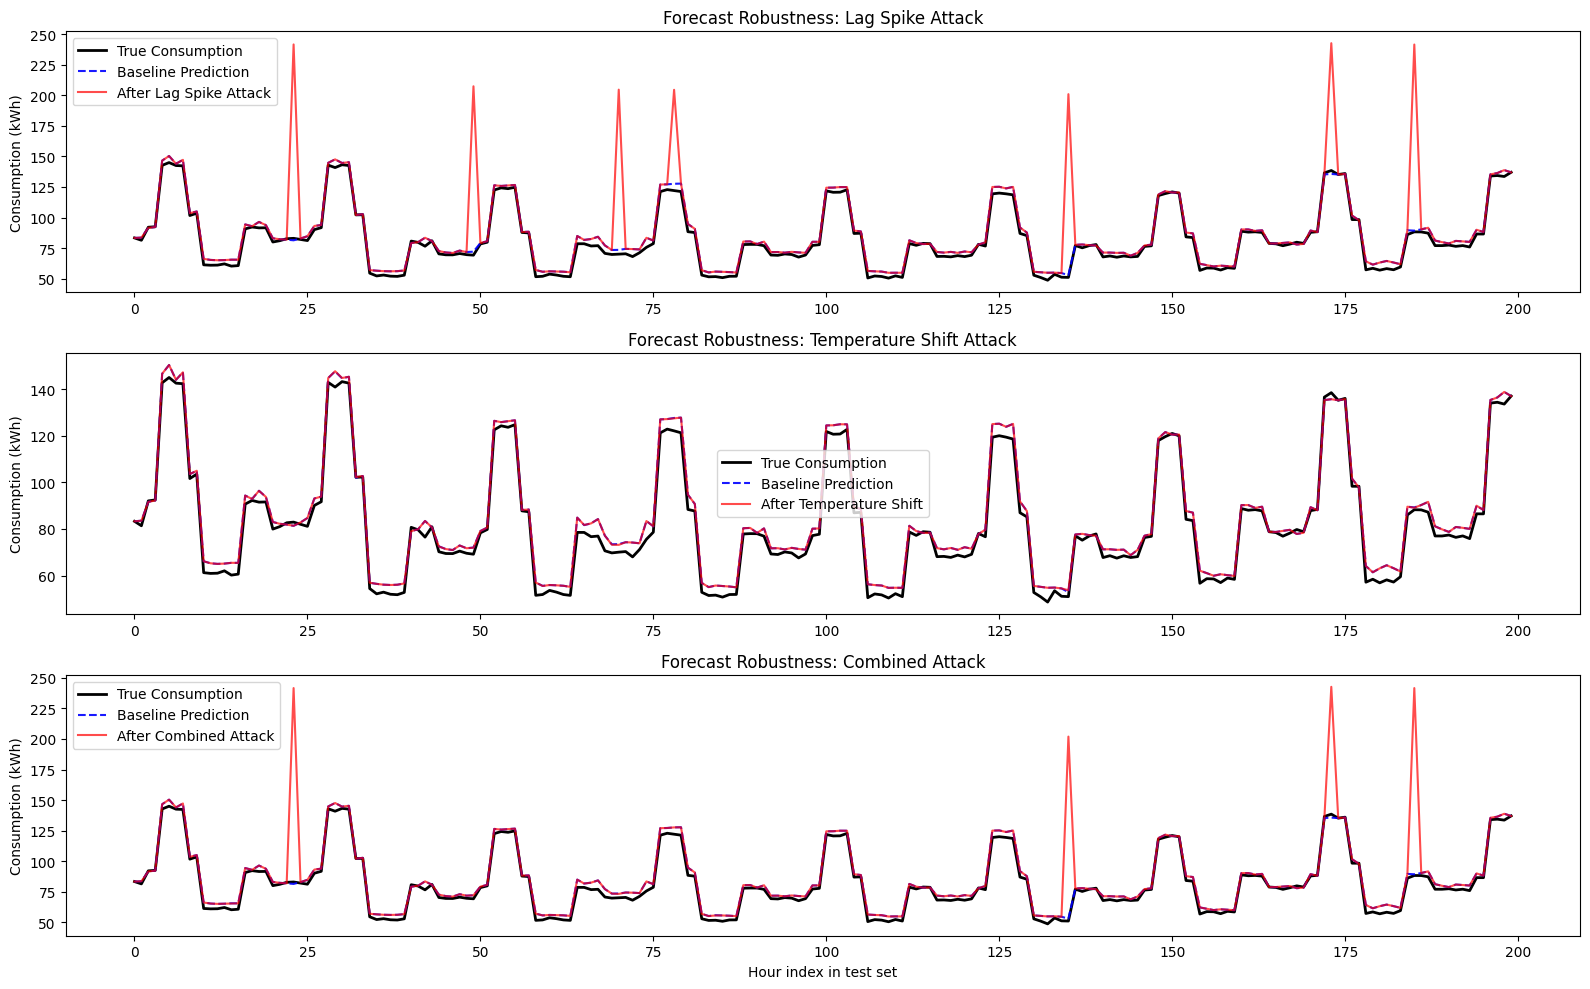

In [17]:
plot_points = 200  # first 200 hours of test set
time_axis = np.arange(plot_points)

plt.figure(figsize=(16, 10))

plt.subplot(3, 1, 1)
plt.plot(time_axis, y_test[:plot_points], 'k-', label='True Consumption', linewidth=2)
plt.plot(time_axis, y_pred_baseline[:plot_points], 'b--', label='Baseline Prediction', alpha=0.9)
plt.plot(time_axis, y_lag[:plot_points], 'r-', label='After Lag Spike Attack', alpha=0.7)
plt.ylabel('Consumption (kWh)')
plt.title('Forecast Robustness: Lag Spike Attack')
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(time_axis, y_test[:plot_points], 'k-', label='True Consumption', linewidth=2)
plt.plot(time_axis, y_pred_baseline[:plot_points], 'b--', label='Baseline Prediction', alpha=0.9)
plt.plot(time_axis, y_temp[:plot_points], 'r-', label='After Temperature Shift', alpha=0.7)
plt.ylabel('Consumption (kWh)')
plt.title('Forecast Robustness: Temperature Shift Attack')
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(time_axis, y_test[:plot_points], 'k-', label='True Consumption', linewidth=2)
plt.plot(time_axis, y_pred_baseline[:plot_points], 'b--', label='Baseline Prediction', alpha=0.9)
plt.plot(time_axis, y_comb[:plot_points], 'r-', label='After Combined Attack', alpha=0.7)
plt.xlabel('Hour index in test set')
plt.ylabel('Consumption (kWh)')
plt.title('Forecast Robustness: Combined Attack')
plt.legend()

plt.tight_layout()
plt.savefig('results/adversarial_robustness.png', dpi=150)
plt.show()

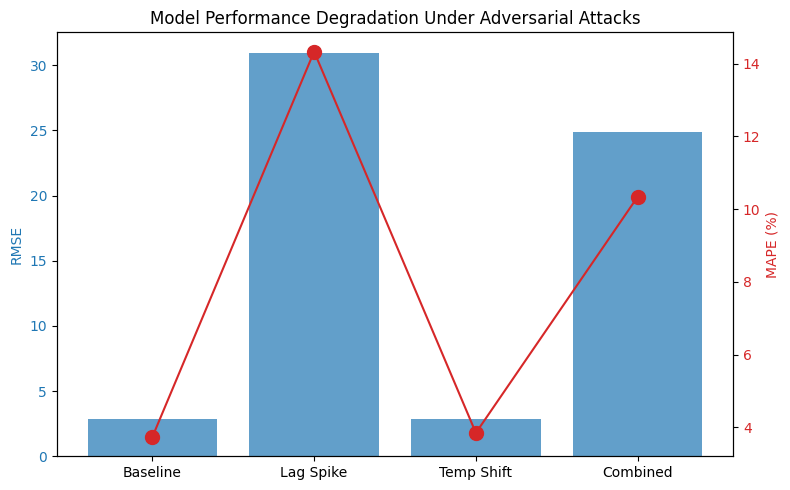

In [18]:
attack_names = ['Baseline', 'Lag Spike', 'Temp Shift', 'Combined']
rmse_vals = [rmse_base, metrics_lag[1], metrics_temp[1], metrics_comb[1]]
mape_vals = [mape_base, metrics_lag[3], metrics_temp[3], metrics_comb[3]]

fig, ax1 = plt.subplots(figsize=(8, 5))
color = 'tab:blue'
ax1.bar(attack_names, rmse_vals, color=color, alpha=0.7)
ax1.set_ylabel('RMSE', color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.plot(attack_names, mape_vals, 'o-', color=color, markerfacecolor=color, markersize=10)
ax2.set_ylabel('MAPE (%)', color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Model Performance Degradation Under Adversarial Attacks')
fig.tight_layout()
plt.savefig('results/attack_metrics_comparison.png', dpi=150)
plt.show()

In [19]:
anomaly_model_path = "../models/anomaly_detector.joblib"
anomaly_model = joblib.load(anomaly_model_path)

test_original_rows = city_df.iloc[split_idx:].copy()
test_original_rows['hour'] = test_original_rows['timestamp'].dt.hour
test_original_rows['day_of_week'] = test_original_rows['timestamp'].dt.dayofweek
anomaly_features = ['total_consumption', 'temperature_c', 'humidity_percent', 'hour', 'day_of_week']
X_anom_orig = test_original_rows[anomaly_features].values
    
pred_orig = anomaly_model.predict(X_anom_orig)
pred_orig = np.where(pred_orig == -1, 1, 0)  # 1 if anomaly
print("Anomaly detector flagged", pred_orig.sum(), "samples in original test set as anomaly.")

X_anom_att = X_anom_orig.copy()
rng = np.random.RandomState(42)
n_att = 50
idx_att = rng.choice(len(X_anom_att), size=n_att, replace=False)
for idx in idx_att:
    X_anom_att[idx, 0] *= rng.uniform(4, 8)  # spike consumption
    
pred_att = anomaly_model.predict(X_anom_att)
pred_att = np.where(pred_att == -1, 1, 0)
detected = pred_att[idx_att].sum()
print(f"After injecting {n_att} extreme consumption spikes, anomaly detector flagged {detected} of them.")
print("This shows the anomaly detector can serve as a complementary defense layer.")

Anomaly detector flagged 25 samples in original test set as anomaly.
After injecting 50 extreme consumption spikes, anomaly detector flagged 49 of them.
This shows the anomaly detector can serve as a complementary defense layer.


C:\Users\AliZibaie\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
C:\Users\AliZibaie\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


In [ ]:
conn.close()